<a href="https://colab.research.google.com/github/hariali-tech/RNN_Model/blob/main/Code_RNN_Model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import re
import string
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np

# ── Upload file in Colab ──
from google.colab import files
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# ── Load dataset ──
df = pd.read_csv(file_name)

print("Dataset loaded!")
print("Shape:", df.shape)
print("\nLabel Distribution:")
print(df['label'].value_counts())
df.head()


Saving CHATGPT.csv to CHATGPT.csv
Dataset loaded!
Shape: (2292, 2)

Label Distribution:
label
NEGATIVE    1264
POSITIVE    1028
Name: count, dtype: int64


,Review,label
0,up to this point i ’ ve mostly been using chat...,NEGATIVE
1,i ’ ve been a user since it ’ s initial roll o...,NEGATIVE
2,this app would almost be perfect if it wasn ’ ...,NEGATIVE
3,"i recently downloaded the app and overall, it'...",POSITIVE
4,i appreciate the devs implementing siri suppor...,NEGATIVE


In [ ]:
import re, string

def preprocess_text(text):
    """Clean raw review text: lowercase, remove URLs, digits, punctuation, extra spaces."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'\d+', '', text)                    # remove digits
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()           # remove extra whitespace
    return text

df['Clean_Review'] = df['Review'].apply(preprocess_text)

# Rename columns for compatibility with rest of notebook
df['Text']  = df['Clean_Review']
df['Label'] = df['label'].map({'NEGATIVE': 'Terrorism', 'POSITIVE': 'Non-Terrorism'})

print("Text Preprocessing Done!")
print("\nOriginal → Cleaned sample:")
print("ORIGINAL:", df['Review'].iloc[0][:150])
print("\nCLEANED :", df['Clean_Review'].iloc[0][:150])
df[['Review','Clean_Review','Label']].head()


Text Preprocessing Done!

Original → Cleaned sample:
ORIGINAL: up to this point i ’ ve mostly been using chatgpt on my windows desktop using google chrome. while it ’ s doable, screen reader navigation is pretty d

CLEANED : up to this point i ’ ve mostly been using chatgpt on my windows desktop using google chrome while it ’ s doable screen reader navigation is pretty dif


,Review,Clean_Review,Label
0,up to this point i ’ ve mostly been using chat...,up to this point i ’ ve mostly been using chat...,Terrorism
1,i ’ ve been a user since it ’ s initial roll o...,i ’ ve been a user since it ’ s initial roll o...,Terrorism
2,this app would almost be perfect if it wasn ’ ...,this app would almost be perfect if it wasn ’ ...,Terrorism
3,"i recently downloaded the app and overall, it'...",i recently downloaded the app and overall its ...,Non-Terrorism
4,i appreciate the devs implementing siri suppor...,i appreciate the devs implementing siri suppor...,Terrorism


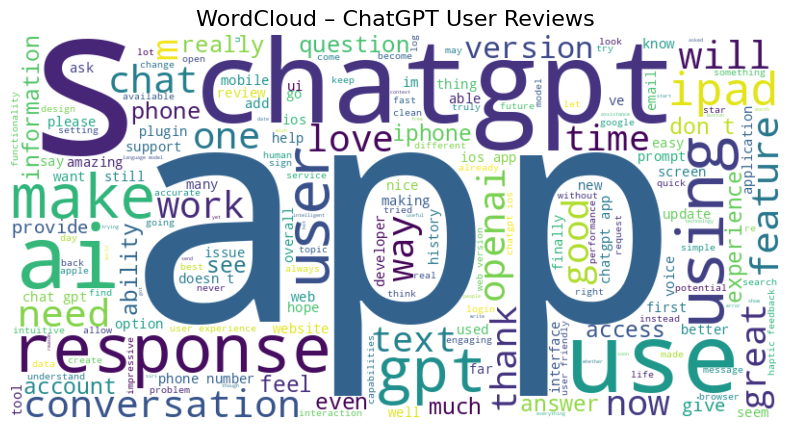

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text_data = ' '.join(df['Text'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud – ChatGPT User Reviews", fontsize=16)
plt.show()


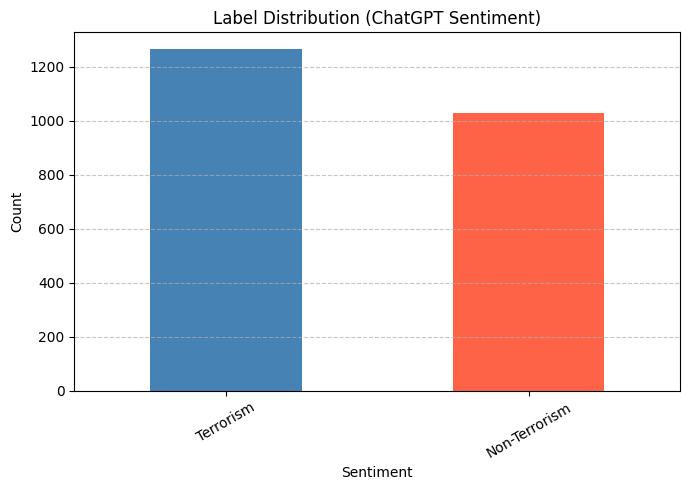

In [ ]:
import matplotlib.pyplot as plt

label_counts = df['Label'].value_counts()

plt.figure(figsize=(7, 5))
label_counts.plot(kind='bar', color=['steelblue','tomato'])
plt.title('Label Distribution (ChatGPT Sentiment)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# Encode Labels: Terrorism=1 (Negative), Non-Terrorism=0 (Positive)
encoder = LabelEncoder()
df["Encoded_Label"] = encoder.fit_transform(df["Label"])
print("Classes:", list(encoder.classes_))
print("\nLabel mapping:")
print(df[['Label','Encoded_Label']].drop_duplicates())
df[['Text','Label','Encoded_Label']].head(8)


Classes: ['Non-Terrorism', 'Terrorism']

Label mapping:
           Label  Encoded_Label
0      Terrorism              1
3  Non-Terrorism              0


,Text,Label,Encoded_Label
0,up to this point i ’ ve mostly been using chat...,Terrorism,1
1,i ’ ve been a user since it ’ s initial roll o...,Terrorism,1
2,this app would almost be perfect if it wasn ’ ...,Terrorism,1
3,i recently downloaded the app and overall its ...,Non-Terrorism,0
4,i appreciate the devs implementing siri suppor...,Terrorism,1
5,no doubt this technology is absolutely life ch...,Terrorism,1
6,please provide a tablet experience on ipad wit...,Terrorism,1
7,chat gpt is seriously underrated dude i mean t...,Non-Terrorism,0


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize text
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(df["Text"])

sequences = tokenizer.texts_to_sequences(df["Text"])
max_length = max(len(seq) for seq in sequences)

# Pad sequences to equal length
X_padded = pad_sequences(sequences, maxlen=max_length, padding='pre')

print("Tokenization + Padding done!")
print("Vocabulary size :", len(tokenizer.word_index))
print("Max sequence len:", max_length)
print("X_padded shape  :", X_padded.shape)


Tokenization + Padding done!
Vocabulary size : 6486
Max sequence len: 436
X_padded shape  : (2292, 436)


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Tokenize Text
tokenizer = Tokenizer(num_words=None, oov_token="<OOV>")
tokenizer.fit_on_texts(df["Text"])

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df["Text"])
print("\nTokenized Sequences:\n", sequences)

# Pad sequences to have same length
max_length = max(len(seq) for seq in sequences)
X_padded = pad_sequences(sequences, maxlen=max_length, padding='pre')
print("\nPadded Sequences Shape:", X_padded.shape)
print("\nPadded Sequences:\n", X_padded)


Tokenized Sequences:
 [[55, 3, 12, 648, 5, 10, 129, 1320, 72, 48, 17, 20, 16, 1467, 318, 48, 237, 2489, 161, 6, 10, 22, 3454, 101, 1321, 1198, 9, 359, 760, 20, 2, 318, 788, 4, 18, 82, 26, 3, 24, 21, 933, 42, 3, 223, 53, 90, 187, 6, 5, 26, 2490, 1078, 1975, 3, 179, 30, 99, 12, 23, 349, 38, 880, 20, 15, 1322, 109, 2, 66, 998, 2491, 2, 56, 8, 359, 92, 1468, 54, 11, 350, 546, 2, 188, 211, 82, 286, 2492, 4, 683, 109, 3, 24, 789, 19, 1323, 2, 101, 1321, 721, 112, 56, 5, 1976, 2, 3455, 11, 12, 233, 2491, 5, 81, 319, 70, 40, 180, 2, 215, 825, 4, 1199, 3, 2, 722, 63, 11, 2, 318, 8, 5, 40, 26, 623, 12, 204, 474, 265, 23, 5, 26, 43, 7, 999, 684, 3456, 116, 414, 5, 1469, 16, 371, 1323, 1470, 3, 497, 1471, 17, 934, 22, 149, 360, 15, 149, 9, 1977, 33, 5, 64, 1324, 2, 116, 330, 498, 11, 2, 149, 2493, 76, 1323, 1718, 1471, 2, 94, 547, 790, 97, 380, 107, 548, 10, 28, 443, 338, 6, 40, 24, 59, 51, 18, 113, 117, 3457, 12, 2494, 33, 15, 6, 649, 10, 28, 339, 1718, 2, 340, 484, 6, 133, 72, 1000, 520, 2, 115

In [ ]:
# Features and Labels
X = X_padded
y = df['Encoded_Label'].values

# Train/Test Split  80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape After Split:")
print("X_train:", X_train.shape, " | X_test:", X_test.shape)
print("y_train:", y_train.shape, " | y_test:", y_test.shape)


Shape After Split:
X_train: (1833, 436)  | X_test: (459, 436)
y_train: (1833,)  | y_test: (459,)


In [ ]:
vocab_size = len(tokenizer.word_index) + 1  # +1 for padding token
print("Vocabulary size (vocab_size):", vocab_size)


Vocabulary size (vocab_size): 6487


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# ✅ Build Simple RNN Model (architecture unchanged)
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_length),
    SimpleRNN(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')   # Binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.build(input_shape=(None, max_length))
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 436, 64)        │       415,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,537 (1.62 MB)

 Trainable params: 425,537 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train Model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.5634 - loss: 0.6814 - val_accuracy: 0.5940 - val_loss: 0.6751
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.7353 - loss: 0.5581 - val_accuracy: 0.6567 - val_loss: 0.6341
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 125ms/step - accuracy: 0.9188 - loss: 0.2669 - val_accuracy: 0.5995 - val_loss: 0.7966
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 0.9768 - loss: 0.0834 - val_accuracy: 0.6458 - val_loss: 0.9219
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - accuracy: 0.9939 - loss: 0.0331 - val_accuracy: 0.6294 - val_loss: 0.9671
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 112ms/step - accuracy: 0.9980 - loss: 0.0179 - val_accuracy: 0.6322 - val_loss: 1.0909
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - accuracy: 0.9693 - loss: 0.0641 - val_accuracy: 0.5913 - val_loss: 0.9393
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.9427 - loss: 0.1853 - val_accuracy: 0

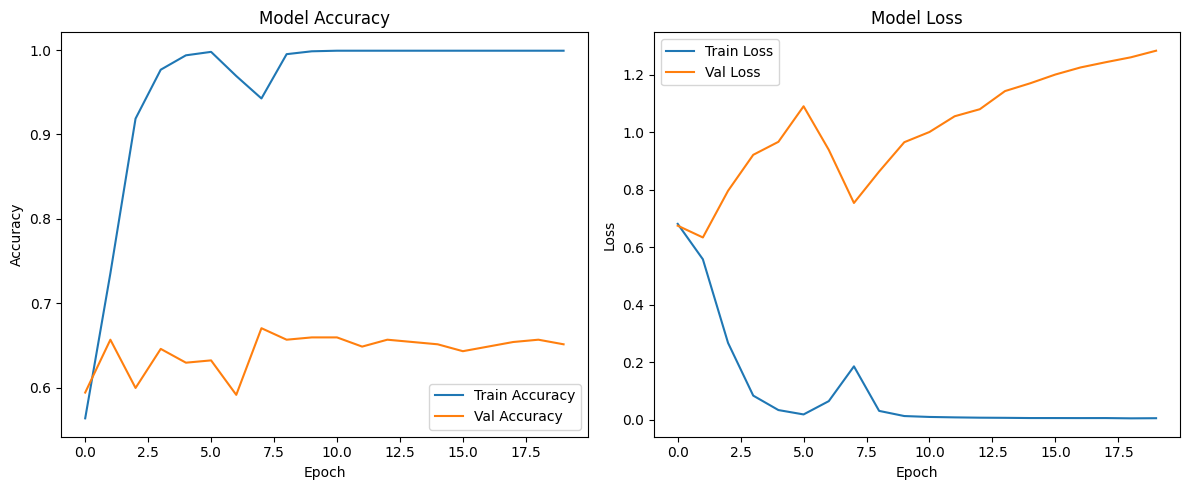

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
#  Evaluate on test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy : {accuracy:.4f}")
print(f"Test Loss     : {loss:.4f}")


Test Accuracy : 0.7124
Test Loss     : 1.0479


In [ ]:
# Raw sigmoid outputs (probabilities)
pred = model.predict(X_test)
pred[:10]


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


array([[9.9986750e-01],
       [9.9420381e-01],
       [5.8707264e-03],
       [9.6112454e-01],
       [9.9610317e-01],
       [5.3177547e-01],
       [2.3056539e-04],
       [9.6945888e-01],
       [1.2479541e-01],
       [3.4572028e-02]], dtype=float32)

In [ ]:
# Convert probabilities to class labels
y_pred = (model.predict(X_test) > 0.5).astype("int32").flatten()

# Decode back to sentiment strings
label_map = {0: 'POSITIVE', 1: 'NEGATIVE'}
y_pred_labels = [label_map[p] for p in y_pred]
y_true_labels = [label_map[t] for t in y_test]

results_df = pd.DataFrame({
    'True Label'     : y_true_labels,
    'Predicted Label': y_pred_labels,
    'Match'          : ['✅' if t==p else '❌' for t,p in zip(y_true_labels, y_pred_labels)]
})
print(results_df.head(20).to_string(index=False))


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
True Label Predicted Label Match
  NEGATIVE        NEGATIVE     ✅
  POSITIVE        NEGATIVE     ❌
  POSITIVE        POSITIVE     ✅
  NEGATIVE        NEGATIVE     ✅
  NEGATIVE        NEGATIVE     ✅
  NEGATIVE        NEGATIVE     ✅
  POSITIVE        POSITIVE     ✅
  NEGATIVE        NEGATIVE     ✅
  NEGATIVE        POSITIVE     ❌
  POSITIVE        POSITIVE     ✅
  POSITIVE        POSITIVE     ✅
  NEGATIVE        NEGATIVE     ✅
  NEGATIVE        NEGATIVE     ✅
  NEGATIVE        POSITIVE     ❌
  NEGATIVE        NEGATIVE     ✅
  POSITIVE        POSITIVE     ✅
  NEGATIVE        NEGATIVE     ✅
  NEGATIVE        NEGATIVE     ✅
  NEGATIVE        NEGATIVE     ✅
  POSITIVE        POSITIVE     ✅


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model.predict(X_test) > 0.5).astype("int32").flatten()
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['POSITIVE', 'NEGATIVE']))


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

📊 Classification Report:
              precision    recall  f1-score   support

    POSITIVE       0.68      0.69      0.69       208
    NEGATIVE       0.74      0.73      0.73       251

    accuracy                           0.71       459
   macro avg       0.71      0.71      0.71       459
weighted avg       0.71      0.71      0.71       459



15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


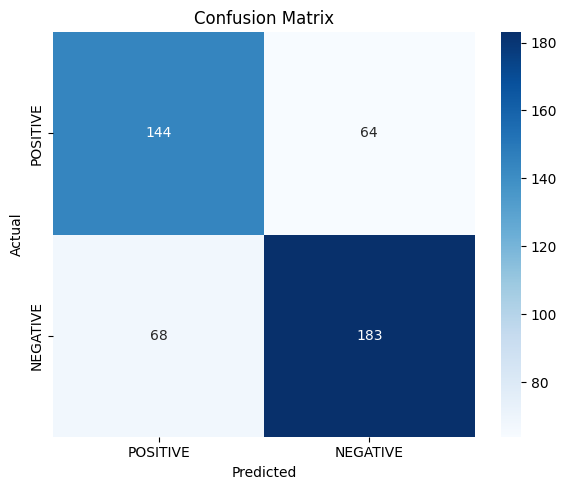

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_pred = (model.predict(X_test) > 0.5).astype("int32").flatten()
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['POSITIVE','NEGATIVE'],
            yticklabels=['POSITIVE','NEGATIVE'])
plt.title('Confusion Matrix')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
